## Algorithmic Selector

Accuracy: 0.8043478260869565


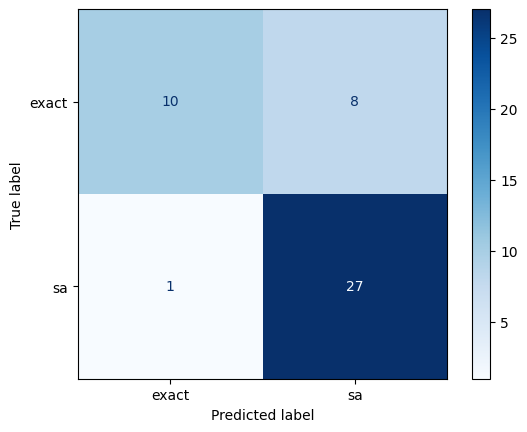

In [11]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("SGP_dataset.csv")

# TODO maybe do preprocessing to filter rows where no algorithm won?
df = df[df['winner'] != 'none']

y = df["winner"]

feature_cols = [
    "num_golfers",
    "num_weeks",
    "group_size",
    "tightness_T",
    "probe_conflicts",
]

X = df[feature_cols]

# Split 65% Train, 35% Test, per assignment definition
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print("Accuracy:", classifier.score(X_test, y_test))

labels = np.unique(y_test)
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.show()

tightness_T        0.369476
num_golfers        0.257928
num_weeks          0.208332
group_size         0.151612
probe_conflicts    0.012652
dtype: float64


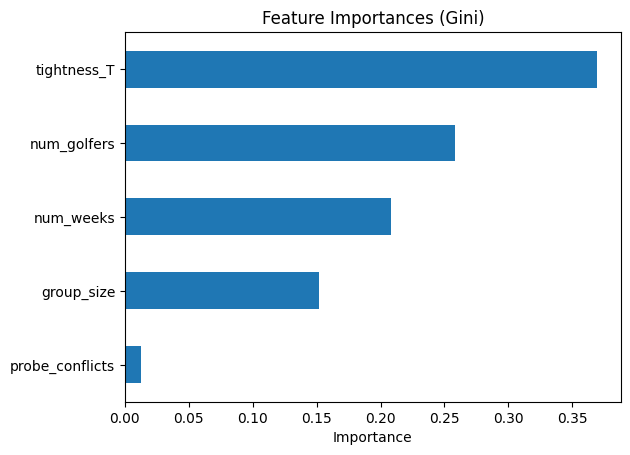

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# After training your model:
importances = classifier.feature_importances_
feature_names = X.columns

# Create a sorted series
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp)

# Plot
feat_imp.plot(kind="barh")
plt.title("Feature Importances (Gini)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

group_size         0.100000
num_weeks          0.021429
tightness_T        0.016667
num_golfers        0.002381
probe_conflicts    0.000000
dtype: float64


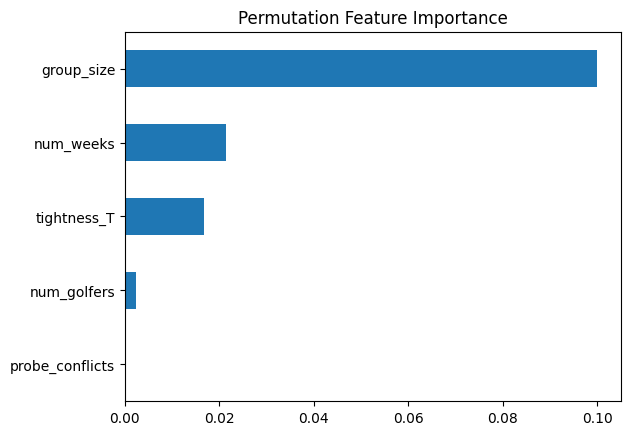

In [10]:
from sklearn.inspection import permutation_importance

result = permutation_importance(classifier, X_test, y_test, n_repeats=30, random_state=42)

perm_imp = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
print(perm_imp)

perm_imp.plot(kind="barh")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.show()